In [1]:
# to plot ATAC & H3K27me3 at anchors of out put from 3 loop callers

In [2]:
import pandas as pd
import pyranges as pr
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
cols = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']
cool_ctrl = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/cooldots_merged_loops_ctrl.bedpe", sep="\t", header=None, names=cols)
cool_rbp1 = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/cooldots_merged_loops_rbp1.bedpe", sep="\t", header=None, names=cols)
mus_ctrl = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/mustache_merged_loops_ctrl_fixed_clean.bedpe", sep="\t", header=None, names=cols)
mus_rbp1 = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/mustache_merged_loops_rbp1_fixed_clean.bedpe", sep="\t", header=None, names=cols)
pk_ctrl = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/peakachu_merged_loops_ctrl.bedpe", sep="\t", header=None, names=cols)
pk_rbp1 = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/peakachu_merged_loops_rbp1.bedpe", sep="\t", header=None, names=cols)

In [4]:
cool_ctrl

,chrom1,start1,end1,chrom2,start2,end2
0,chr1,3900000,3910000,chr1,4820000,4830000
1,chr1,4090000,4100000,chr1,5600000,5610000
2,chr1,5500000,5510000,chr1,5620000,5630000
3,chr1,5510000,5520000,chr1,5740000,5750000
4,chr1,5630000,5640000,chr1,5750000,5760000
...,...,...,...,...,...,...
8547,chrY,11010000,11020000,chrY,11290000,11300000
8548,chrY,11300000,11310000,chrY,11720000,11730000
8549,chrY,11520000,11530000,chrY,11710000,11720000
8550,chrY,11525000,11530000,chrY,11680000,11685000


In [5]:
mus_ctrl

,chrom1,start1,end1,chrom2,start2,end2
0,chr1,1110000,1120000,chr1,1260000,1270000
1,chr1,1120000,1125000,chr1,1245000,1250000
2,chr1,1770000,1780000,chr1,1890000,1900000
3,chr1,1950000,1960000,chr1,2040000,2050000
4,chr1,2200000,2210000,chr1,2380000,2390000
...,...,...,...,...,...,...
12968,chrY,10910000,10920000,chrY,11310000,11320000
12969,chrY,10980000,10985000,chrY,11295000,11300000
12970,chrY,11000000,11010000,chrY,11290000,11300000
12971,chrY,12920000,12930000,chrY,13340000,13350000


In [6]:
pk_ctrl

,chrom1,start1,end1,chrom2,start2,end2
0,chr1,3910000,3920000,chr1,4590000,4600000
1,chr1,5500000,5510000,chr1,5620000,5630000
2,chr1,5500000,5510000,chr1,5740000,5750000
3,chr1,5630000,5640000,chr1,5740000,5750000
4,chr1,5635000,5640000,chr1,5980000,5985000
...,...,...,...,...,...,...
11865,chrX,152645000,152650000,chrX,152815000,152820000
11866,chrX,152830000,152835000,chrX,152870000,152875000
11867,chrX,154730000,154740000,chrX,154840000,154850000
11868,chrX,154915000,154920000,chrX,155145000,155150000


In [7]:
"""
left_cool_ctrl=cool_ctrl.iloc[:, [0,1,2]].copy()
right_cool_ctrl=cool_ctrl.iloc[:, [3,4,5]].copy()
left_cool_ctrl.columns = ['chrom', 'start', 'end']
right_cool_ctrl.columns = ['chrom', 'start', 'end']
all_anchors=pd.concat([left_cool_ctrl, right_cool_ctrl], ignore_index=True)
all_anchors
"""

"\nleft_cool_ctrl=cool_ctrl.iloc[:, [0,1,2]].copy()\nright_cool_ctrl=cool_ctrl.iloc[:, [3,4,5]].copy()\nleft_cool_ctrl.columns = ['chrom', 'start', 'end']\nright_cool_ctrl.columns = ['chrom', 'start', 'end']\nall_anchors=pd.concat([left_cool_ctrl, right_cool_ctrl], ignore_index=True)\nall_anchors\n"

In [8]:
def get_anchors(df):
    left = df.iloc[:, [0, 1, 2]].copy()
    right = df.iloc[:, [3, 4, 5]].copy()
    left.columns = ['chrom', 'start', 'end']
    right.columns = ['chrom', 'start', 'end']
    anchors = pd.concat([left, right], ignore_index=True)
    anchors = anchors.drop_duplicates()
    anchors = anchors.sort_values(['chrom', 'start', 'end']).reset_index(drop=True)
    return anchors

In [9]:
allanchors_cool_ctrl = get_anchors(cool_ctrl)
allanchors_cool_rbp1 = get_anchors(cool_rbp1)
allanchors_mus_ctrl = get_anchors(mus_ctrl)
allanchors_mus_rbp1 = get_anchors(mus_rbp1)
allanchors_pk_ctrl = get_anchors(pk_ctrl)
allanchors_pk_rbp1 = get_anchors(pk_rbp1)

In [10]:
allanchors_mus_rbp1

,chrom,start,end
0,chr1,980000,990000
1,chr1,1110000,1120000
2,chr1,1260000,1270000
3,chr1,1270000,1280000
4,chr1,1760000,1770000
...,...,...,...
19479,chrY,11690000,11700000
19480,chrY,12920000,12930000
19481,chrY,13340000,13350000
19482,chrY,13490000,13500000


In [11]:
allanchors_cool_ctrl.to_csv("anchors_cool_ctrl.bed", sep="\t", header=False, index=False)
allanchors_cool_rbp1.to_csv("anchors_cool_rbp1.bed", sep="\t", header=False, index=False)
allanchors_mus_ctrl.to_csv("anchors_mus_ctrl.bed", sep="\t", header=False, index=False)
allanchors_mus_rbp1.to_csv("anchors_mus_rbp1.bed", sep="\t", header=False, index=False)
allanchors_pk_ctrl.to_csv("anchors_pk_ctrl.bed", sep="\t", header=False, index=False)
allanchors_pk_rbp1.to_csv("anchors_pk_rbp1.bed", sep="\t", header=False, index=False)

In [12]:
#### Now do computeMatrix and plotheatmap

In [13]:
#atac="/usr/users/papantonis1/aman/atac_gata6study_WT/results/bwa/merged_replicate/bigwig/WT.mRp.clN.bigWig"
"""
(cool_notebook) [papantonis1@gwdu101 ~]$ bigWigInfo /usr/users/papantonis1/aman/atac_gata6study_WT/results/bwa/merged_replicate/bigwig/WT.mRp.clN.bigWig
version: 4
isCompressed: yes
isSwapped: 0
primaryDataSize: 867,841,933
primaryIndexSize: 7,224,892
zoomLevels: 10
chromCount: 429
basesCovered: 2,825,328,339
mean: 0.045854
min: 0.003457
max: 48.159000
std: 0.103600
"""

#/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/compute_matrix_atac.sh
#/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/compute_matrix_h3k27me3.sh

'\n(cool_notebook) [papantonis1@gwdu101 ~]$ bigWigInfo /usr/users/papantonis1/aman/atac_gata6study_WT/results/bwa/merged_replicate/bigwig/WT.mRp.clN.bigWig\nversion: 4\nisCompressed: yes\nisSwapped: 0\nprimaryDataSize: 867,841,933\nprimaryIndexSize: 7,224,892\nzoomLevels: 10\nchromCount: 429\nbasesCovered: 2,825,328,339\nmean: 0.045854\nmin: 0.003457\nmax: 48.159000\nstd: 0.103600\n'

In [14]:
## Loop length and loop span

# func to get both
def compute_loop_metrics(df):
    loop_length = (df['end1'] - df['start1']) + (df['end2'] - df['start2'])
    loop_span = abs((df['start2'] + df['end2']) / 2 - (df['start1'] + df['end1']) / 2)
    return loop_length.mean(), loop_span.mean()

# Store metrics
results = []

# as defined above
datasets = {
    "cool_ctrl": cool_ctrl,
    "cool_rbp1": cool_rbp1,
    "mus_ctrl": mus_ctrl,
    "mus_rbp1": mus_rbp1,
    "pk_ctrl": pk_ctrl,
    "pk_rbp1": pk_rbp1
}

# iterate and store in a dic
for name, df in datasets.items():
    avg_length, avg_span = compute_loop_metrics(df)
    results.append({
        "dataset": name,
        "avg_loop_length": round(avg_length, 2),
        "avg_loop_span": round(avg_span, 2)
    })

# Convert dic to df
metrics_df = pd.DataFrame(results)
print(metrics_df)

     dataset  avg_loop_length  avg_loop_span
0  cool_ctrl         18779.23      404629.33
1  cool_rbp1         18900.21      399782.29
2   mus_ctrl         16922.07      374795.73
3   mus_rbp1         17219.05      374003.42
4    pk_ctrl         15693.34      352264.95
5    pk_rbp1         16380.16      361546.76


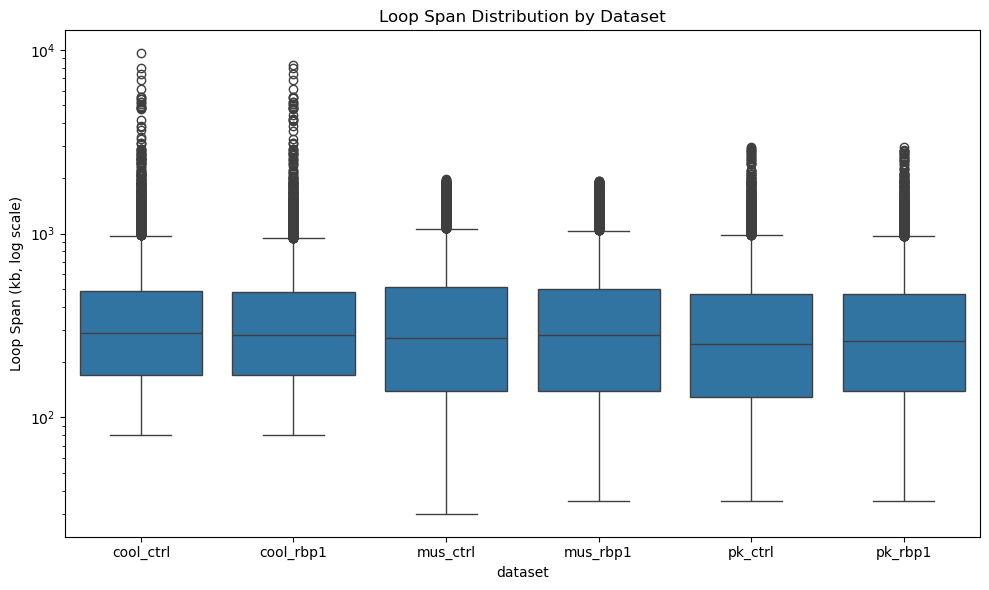

In [15]:
# Add loop span and loop length in kilobases
for name, df in datasets.items():
    df["loop_length_kb"] = ((df["end1"] - df["start1"]) + (df["end2"] - df["start2"])) / 1000
    df["loop_span_kb"] = abs((df["start2"] + df["end2"]) / 2 - (df["start1"] + df["end1"]) / 2) / 1000
    df["dataset"] = name

# Concatenate all into one long DataFrame
merged_df = pd.concat(datasets.values(), ignore_index=True)

# Plot loop span (in kb) on log scale
plt.figure(figsize=(10, 6))
sns.boxplot(x="dataset", y="loop_span_kb", data=merged_df)
plt.yscale("log")
plt.ylabel("Loop Span (kb, log scale)")
plt.title("Loop Span Distribution by Dataset")
plt.tight_layout()
plt.show()

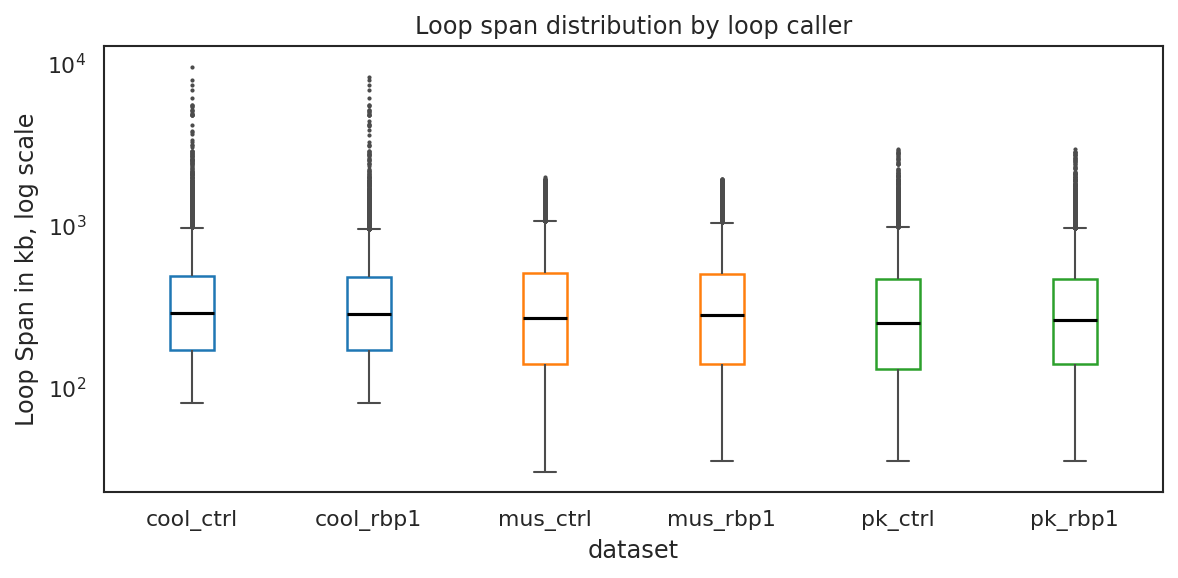

In [30]:
tool_colors = {
    "cool_ctrl": "#1f77b4",  # blue
    "cool_rbp1": "#1f77b4",
    "mus_ctrl": "#ff7f0e",   # orange
    "mus_rbp1": "#ff7f0e",
    "pk_ctrl": "#2ca02c",    # green
    "pk_rbp1": "#2ca02c"
}

sns.set(style="white", context="paper", font_scale=1.2)

plt.figure(figsize=(8, 4), dpi=150)
ax = sns.boxplot(
    x="dataset",
    y="loop_span_kb",
    data=merged_df,
    width=0.25,
    fliersize=1,
    linewidth=1,
    showcaps=True,
    boxprops=dict(facecolor='none'),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
    medianprops=dict(linewidth=1.5, color='black')
)

for patch, label in zip(ax.patches, merged_df["dataset"].unique()):
    patch.set_edgecolor(tool_colors[label])
    patch.set_linewidth(1.2)

plt.yscale("log")
plt.ylabel("Loop Span in kb, log scale")
plt.title("Loop span distribution by loop caller")
plt.tight_layout()
plt.show()